In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
sys.path.append(os.path.abspath(".."))

from src.utils.rate_utils import GetRates
from src.rates.hull_white import HullWhite

In [2]:
# loading yield curves
df = pd.read_csv(
    "../data/processed/cleaned_yield_curve_fred.csv",
    index_col = 'date',
    parse_dates = True
)

# extracting latest yield curve
curve = GetRates().get_latest_curve(df)

# extracting initial short rate
r0 = GetRates().get_short_rate(curve)

# initializing HW model
int_rate_model = HullWhite(
    a = 0.1,
    sigma = 0.01,
    initial_rate = r0,
    theta = np.mean(list(curve.values()))
)

# simulating interest rate paths
n_paths = 1000
n_steps = 60
dt = 1.0 # yearly

paths = int_rate_model.simulate_paths(
    n_paths = n_paths,
    n_steps = n_steps,
    dt = dt
)

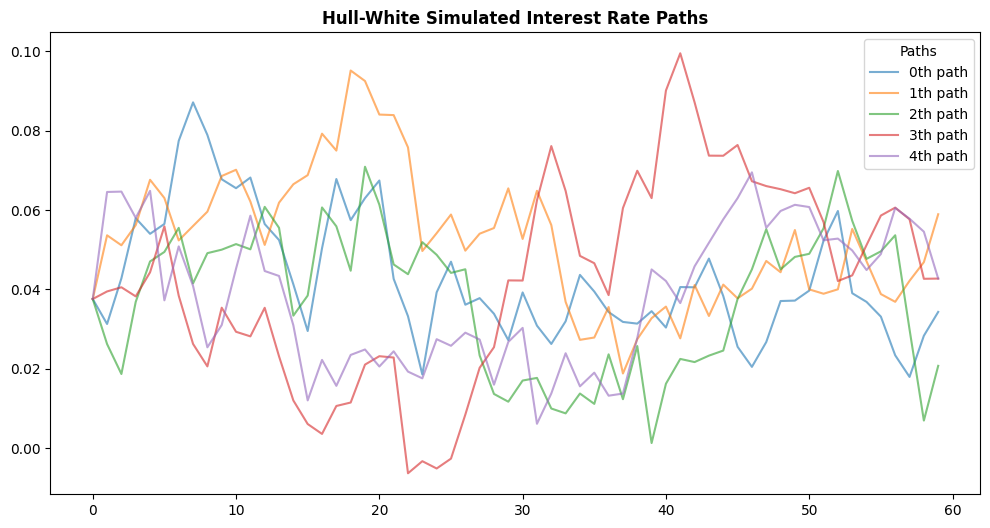

In [3]:
# visualization of simulated interest paths
plt.figure(figsize=((12, 6)))

for i in range(5):
    plt.plot(paths[i], alpha = 0.6, label = f"{i}th path")

plt.legend(loc='upper right', title = 'Paths')
plt.title("Hull-White Simulated Interest Rate Paths", fontweight = 'bold')
plt.show()

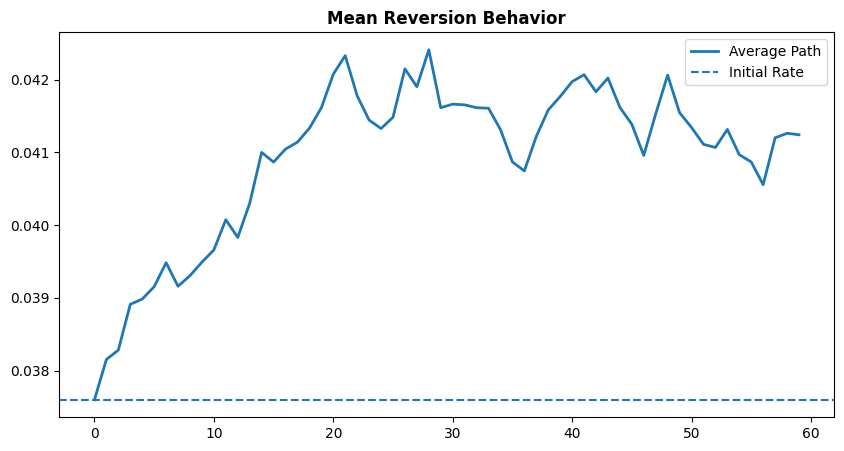

In [5]:
# mean reversion check
mean_path = paths.mean(axis = 0)

plt.figure(figsize=(10, 5))
plt.plot(mean_path, label = 'Average Path', linewidth = 2)
plt.axhline(r0, linestyle = '--', label = 'Initial Rate')
plt.title('Mean Reversion Behavior', fontweight = 'bold')
plt.legend(loc = 'upper right')
plt.show()

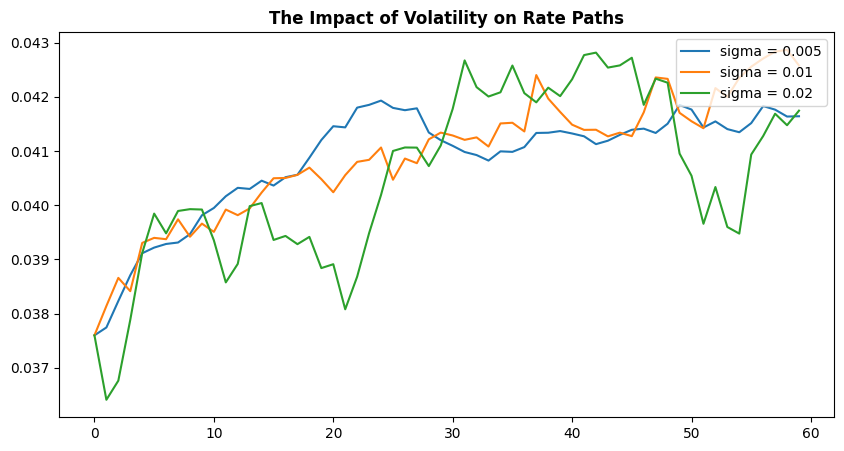

In [9]:
# simulated rates for a given set of different volatilities
sigmas = [0.005, 0.01, 0.02]

plt.figure(figsize=(10, 5))

for sigma in sigmas:
    model = HullWhite(
        a = 0.1,
        sigma = sigma,
        initial_rate = r0,
        theta = np.mean(list(curve.values()))
    )

    paths = model.simulate_paths(
        n_paths = n_paths,
        n_steps = n_steps,
        dt = dt
    )

    mean_path = paths.mean(axis = 0)
    plt.plot(mean_path, label = f'sigma = {sigma}')

plt.title('The Impact of Volatility on Rate Paths', fontweight = 'bold')
plt.legend(loc = 'upper right')
plt.show()   

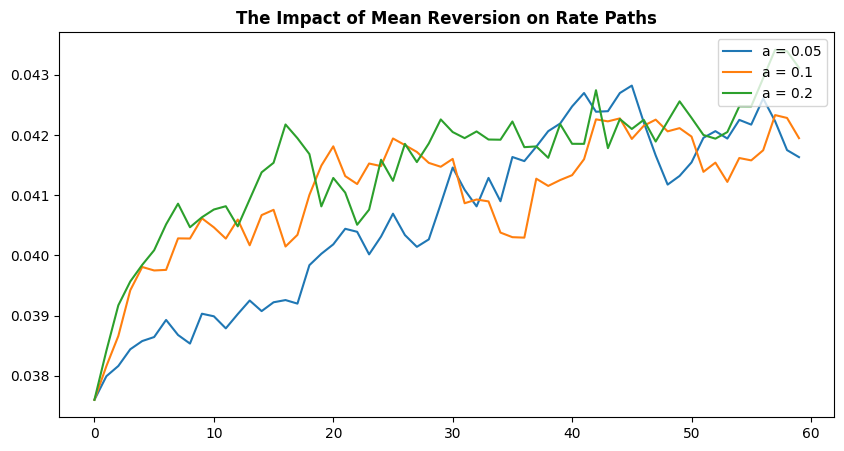

In [10]:
# simulated rates for a given set of different volatilities
a_values = [0.05, 0.1, 0.2]

plt.figure(figsize=(10, 5))

for a in a_values:
    model = HullWhite(
        a = a,
        sigma = 0.01,
        initial_rate = r0,
        theta = np.mean(list(curve.values()))
    )

    paths = model.simulate_paths(
        n_paths = n_paths,
        n_steps = n_steps,
        dt = dt
    )

    mean_path = paths.mean(axis = 0)
    plt.plot(mean_path, label = f'a = {a}')

plt.title('The Impact of Mean Reversion on Rate Paths', fontweight = 'bold')
plt.legend(loc = 'upper right')
plt.show() 